<a href="https://colab.research.google.com/github/velizabetho/mineria/blob/main/proyecto_base_mineria_evaluacion3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Base - Evaluación de Minería de Datos

## Información del Grupo

- **Nombre o Número de Grupo:** Cafetería
- **Sección:** 004D
- **Fecha de Entrega:** 02/06/2026

---

## Integrantes del Grupo (máximo 3 estudiantes)

### Estudiante 1
- **Nombre:** Tomás
- **Apellido:** Duhalde
- **Correo institucional:** to.duhalde@duocuc.cl

### Estudiante 2
- **Nombre:** Valentina
- **Apellido:** Olivares
- **Correo institucional:** va.olivaresp@duocuc.cl


---

## Tema del Proyecto
Predicción de la categoría de productos en ventas de cafetería.
El objetivo de este proyecto es predecir qué categoría de producto (café, té, panadería, etc) es más probable que compre un cliente, en función de la ubicación de la sucursal, la hora del día en que realiza la compra y el precio unitario del producto.

---

## Descripción del Proyecto
El contexto del problema es la industria del retail, específicamente en el área gastronómica, es importante conocer los patrones de consumo para poder tomar decisiones que beneficien al negocio. Este modelo sirve para todo aquel que busque realizar un analisis de sus ventas y predicciones de estas en base a las diversas categorás de productos que manejan.

---

## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), utilizada ampliamente para abordar proyectos de ciencia de datos y machine learning. Se compone de seis fases fundamentales:

---

## Fases de CRISP-DM

### 1. Comprensión del Negocio
Describa el objetivo del proyecto desde una perspectiva práctica o social. ¿Qué decisión se espera mejorar gracias al modelo?

---

### 2. Comprensión de los Datos
- Describa la fuente del dataset
- Número de registros y columnas
- Variables objetivo y predictoras
- Tipos de datos: numéricos, categóricos, fechas, etc.

---

### 3. Preparación de los Datos

#### a. Limpieza de Datos
- Eliminación o imputación de valores nulos
- Corrección de errores y outliers
- Revisión de duplicados

#### b. Transformaciones y Encoding
- Normalización, estandarización, escalamiento si aplica
- Codificación de variables categóricas (OneHotEncoding, LabelEncoder)
- Selección o ingeniería de características (feature selection/engineering)

---

### 4. Análisis Exploratorio de Datos
- Estadísticas descriptivas
- Visualizaciones significativas: histogramas, boxplots, gráficos de dispersión, mapas de calor, etc.
- Hipótesis o tendencias observadas

---

### 5. Modelado y Justificación

#### a. Tipo de problema
- ¿Se trata de clasificación o regresión?

#### b. Modelo(s) utilizados
- Algoritmo seleccionado (Regresión lineal, árbol de decisión, SVM, etc.)
- Justificación teórica y empírica del modelo
- Parámetros utilizados (si aplica)

---

### 6. Evaluación del Modelo
- División entrenamiento/prueba o validación cruzada
- Métricas reportadas:
  - Clasificación: Accuracy, Precision, Recall, F1-score
  - Regresión: RMSE, MAE, R²
- Análisis de errores y limitaciones

---

### 7. Conclusiones y Recomendaciones
- Interpretación de los resultados del modelo
- Limitaciones del análisis
- Propuestas de mejora o posibles extensiones del proyecto
- Aplicabilidad en un contexto real

---

## Recomendaciones Finales

- Documente cada etapa con claridad, justificando sus decisiones con fundamentos teóricos o exploratorios.
- Use visualizaciones para apoyar sus conclusiones.
- Acompañe su informe con código limpio y bien comentado.
- Recuerde que el proceso analítico y reflexivo es más valioso que lograr "el mejor modelo".

---


## 1. Comprensión del Negocio
Describa brevemente el problema o fenómeno que desea analizar.

In [1]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
!pip install category_encoders

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import category_encoders as ce
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
df = pd.read_excel("/content/CoffeeShopSales.xlsx")

## 2. Comprensión de los Datos
Describa la fuente de los datos, número de registros, atributos, tipo de variables, etc.

In [6]:
df.head(10)

#Mostrar las 10 primeras lineas del DataFrame

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
5,6,2023-01-01,07:22:41,1,5,Lower Manhattan,77,3.00,Bakery,Scone,Oatmeal Scone
6,7,2023-01-01,07:25:49,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
7,8,2023-01-01,07:33:34,2,5,Lower Manhattan,28,2.00,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm
8,9,2023-01-01,07:39:13,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg
9,10,2023-01-01,07:39:34,2,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate,Dark chocolate Rg


In [7]:
df.shape

(149116, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [9]:
df["transaction_id"].nunique()

149116

In [10]:
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

#Busca los valores nulos

Total de valores nulos de transaction_id = 0
Total de valores nulos de transaction_date = 0
Total de valores nulos de transaction_time = 0
Total de valores nulos de transaction_qty = 0
Total de valores nulos de store_id = 0
Total de valores nulos de store_location = 0
Total de valores nulos de product_id = 0
Total de valores nulos de unit_price = 0
Total de valores nulos de product_category = 0
Total de valores nulos de product_type = 0
Total de valores nulos de product_detail = 0


In [11]:
tipos = df.columns.to_series().groupby(df.dtypes).groups #agrupación de las columnas de tipo de datos

In [12]:
ctext = tipos [np.dtype('object')]  #conociendo las columnas por tipo de datos
len(ctext)                          #cantidad de columnas con datos categóricos

5

In [13]:
columnas = df.columns                     #Conociendo la lista de columnas numericas
cnum = list(set(columnas) - set(ctext))
len(cnum)

6

In [14]:
df.isnull().any().any()

np.False_

In [15]:
df['store_location'].unique().tolist()

#conocer las sucursales fisicas

['Lower Manhattan', "Hell's Kitchen", 'Astoria']

In [16]:
df['product_category'].unique().tolist()

#Conocer las categorias que estan organizados los productos

['Coffee',
 'Tea',
 'Drinking Chocolate',
 'Bakery',
 'Flavours',
 'Loose Tea',
 'Coffee beans',
 'Packaged Chocolate',
 'Branded']

In [17]:
df['product_type'].unique().tolist()

#Conocer los productos que se venden

['Gourmet brewed coffee',
 'Brewed Chai tea',
 'Hot chocolate',
 'Drip coffee',
 'Scone',
 'Barista Espresso',
 'Brewed Black tea',
 'Brewed Green tea',
 'Brewed herbal tea',
 'Biscotti',
 'Pastry',
 'Organic brewed coffee',
 'Premium brewed coffee',
 'Regular syrup',
 'Herbal tea',
 'Gourmet Beans',
 'Organic Beans',
 'Sugar free syrup',
 'Drinking Chocolate',
 'Premium Beans',
 'Chai tea',
 'Green beans',
 'Espresso Beans',
 'Green tea',
 'Organic Chocolate',
 'Housewares',
 'Black tea',
 'House blend Beans',
 'Clothing']

In [18]:
df['product_detail'].unique().tolist()

#Conocer detalles/caracteristicas de los productos

['Ethiopia Rg',
 'Spicy Eye Opener Chai Lg',
 'Dark chocolate Lg',
 'Our Old Time Diner Blend Sm',
 'Oatmeal Scone',
 'Columbian Medium Roast Sm',
 'Latte Rg',
 'Dark chocolate Rg',
 'Spicy Eye Opener Chai Rg',
 'Ethiopia Lg',
 'Earl Grey Lg',
 'Ouro Brasileiro shot',
 'Serenity Green Tea Lg',
 'Jumbo Savory Scone',
 'Lemon Grass Rg',
 'Sustainably Grown Organic Lg',
 'Hazelnut Biscotti',
 'Cappuccino',
 'Lemon Grass Lg',
 'Chocolate Chip Biscotti',
 'Peppermint Lg',
 'Chocolate Croissant',
 'Latte',
 'Brazilian Rg',
 'Brazilian Lg',
 'Columbian Medium Roast Rg',
 'Morning Sunrise Chai Rg',
 'Morning Sunrise Chai Lg',
 'Our Old Time Diner Blend Lg',
 'Sustainably Grown Organic Rg',
 'Scottish Cream Scone ',
 'Peppermint Rg',
 'English Breakfast Rg',
 'Our Old Time Diner Blend Rg',
 'Serenity Green Tea Rg',
 'Brazilian Sm',
 'Jamaican Coffee River Sm',
 'Jamaican Coffee River Lg',
 'Ginger Biscotti',
 'Traditional Blend Chai Lg',
 'Cappuccino Lg',
 'Espresso shot',
 'Earl Grey Rg',
 'Gi

## 3. Preparación de los Datos
Detalle los pasos de limpieza y transformación de datos.

- Eliminación de nulos
- Conversión de categorías
- Normalización o estandarización

In [19]:
df['total_sales'] = df['transaction_qty'] * df['unit_price']

#Nueva columna llamada "Total_Sales" que es igual a las transacciones multiplicado por el precio

In [20]:
sales_by_category = df.groupby('product_category')['total_sales'].sum()

#Operacion para poder saber cuantas ganancia se recolecto en las ventas de cada categoría

In [21]:
df['hour'] = pd.to_datetime(df['transaction_time'].astype(str), format='%H:%M:%S').dt.hour

#Extraemos la hora en que se realiza la venta

In [22]:
columnas_relevantes = ['hour', 'store_location', 'unit_price', 'product_category']
df_modelo = df[columnas_relevantes].copy()

#Creamos un nuevo dataset solo con las columnas que se utilizarán para el modelado

In [23]:
X = df_modelo[['hour', 'store_location', 'unit_price']]
y = df_modelo['product_category']

#Definimos variables para modelado

#### 3.1 Depuración de Datos
- Manejo de valores nulos
- Detección y tratamiento de outliers
- Corrección de errores de tipeo

In [24]:
sales_by_category

,total_sales
product_category,
Bakery,82315.64
Branded,13607.00
Coffee,269952.45
Coffee beans,40085.25
Drinking Chocolate,72416.00
Flavours,8408.80
Loose Tea,11213.60
Packaged Chocolate,4407.64
Tea,196405.95


#### 3.2 Encoding (si aplica)
- Transformaciones aplicadas a variables categóricas (OneHotEncoding, LabelEncoding, etc.)


In [25]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
category_encoded = ohe.fit_transform(df[['product_category']])

#Debido a que la matriz de correlacion no entrego una relación aplicaremos endcoding a todas las columnas categoricas para poder volver a crear la matriz

In [26]:
category_encoded = pd.DataFrame(category_encoded, columns=ohe.get_feature_names_out(['product_category']),index=df.index)

#Preparación de endcoding

In [27]:
category_encoded.head(5)

#mostrando testeo de endcoding

#endCoding de la columna category

,product_category_Branded,product_category_Coffee,product_category_Coffee beans,product_category_Drinking Chocolate,product_category_Flavours,product_category_Loose Tea,product_category_Packaged Chocolate,product_category_Tea
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [28]:
category_encoded_2 = ohe.fit_transform(df[['store_location']])

#endCoding de store_Location usando one hot encoding

In [29]:
category_encoded_2 = pd.DataFrame(category_encoded_2, columns=ohe.get_feature_names_out(['store_location']),index=df.index)

#endCoding de la columna store_location

In [30]:
category_encoded_2.head(30)

,store_location_Hell's Kitchen,store_location_Lower Manhattan
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
5,0.0,1.0
6,0.0,1.0
7,0.0,1.0
8,0.0,1.0
9,0.0,1.0


In [31]:
X_numeric = X[['hour', 'unit_price']]

In [32]:
X = pd.concat([X_numeric, category_encoded_2], axis=1)

In [33]:
display(X.head(10))

#Después de realizar encodings necesarios, revisamos variables predictoras

,hour,unit_price,store_location_Hell's Kitchen,store_location_Lower Manhattan
0,7,3.00,0.0,1.0
1,7,3.10,0.0,1.0
2,7,4.50,0.0,1.0
3,7,2.00,0.0,1.0
4,7,3.10,0.0,1.0
5,7,3.00,0.0,1.0
6,7,2.00,0.0,1.0
7,7,2.00,0.0,1.0
8,7,4.25,0.0,1.0
9,7,3.50,0.0,1.0


In [34]:
product_type_encoding = ohe.fit_transform(df[['product_type']])

In [35]:
product_type_encoding = pd.DataFrame(product_type_encoding, columns=ohe.get_feature_names_out(['product_type']),index=df.index)

In [36]:
product_type_encoding = product_type_encoding.rename(columns={
    'product_type_Barista Espresso': 'Barista_Espresso',
    'product_type_Biscotti': 'Biscotti',
    'product_type_Black tea': 'Black_tea',
    'product_type_Brewed Black tea': 'Brewed_Black_tea',
    'product_type_Brewed Chai tea': 'Brewed_Chai_tea',
    'product_type_Brewed Green tea': 'Brewed_Green_tea',
    'product_type_Brewed herbal tea': 'Brewed_herbal_tea',
    'product_type_Chai tea': 'Chai_tea',
    'product_type_Clothing': 'Clothing',
    'product_type_Drinking Chocolate': 'Drinking_Chocolate',
    'product_type_Drip coffee': 'Drip_coffee',
    'product_type_Espresso Beans': 'Espresso_Beans',
    'product_type_Gourmet Beans': 'Gourmet_Beans',
    'product_type_Gourmet brewed coffee': 'Gourmet_brewed_coffee',
    'product_type_Green beans': 'Green_beans',
    'product_type_Green tea': 'Green_tea',
    'product_type_Herbal tea': 'Herbal_tea',
    'product_type_Hot chocolate': 'Hot_chocolate',
    'product_type_House blend Beans': 'House_blend_Beans',
    'product_type_Housewares': 'Housewares',
    'product_type_Organic Beans': 'Organic_Beans',
    'product_type_Organic Chocolate': 'Organic_Chocolate',
    'product_type_Organic brewed coffee': 'Organic_brewed_coffee',
    'product_type_Pastry': 'Pastry',
    'product_type_Premium Beans': 'Premium_Beans',
    'product_type_Premium brewed coffee': 'Premium_brewed_coffee',
    'product_type_Regular syrup': 'Regular_syrup',
    'product_type_Scone': 'Scone',
    'product_type_Sugar free syrup': 'Sugar_free_syrup'
})

In [37]:
df_final = pd.concat([
    df,
    category_encoded,
    category_encoded_2,
    product_type_encoding
], axis=1)

#Concadenamos las nuevas columnas con valores numericos que se pueden trabajar en la matriz :3

In [38]:
df_final = df_final.drop(columns=[
    'store_location',
    'product_category',
    'product_type',
    'product_detail',
])

#Borramos las columnas categorias para evitar redundancia innecesaria y ademas borramos otras columnas que no agregagan valor a nuestra matriz

## 4. Análisis Exploratorio
Describa con texto y **agregue gráficos** del análisis.

- Histogramas
- Correlaciones
- Boxplots
- Distribuciones por clase

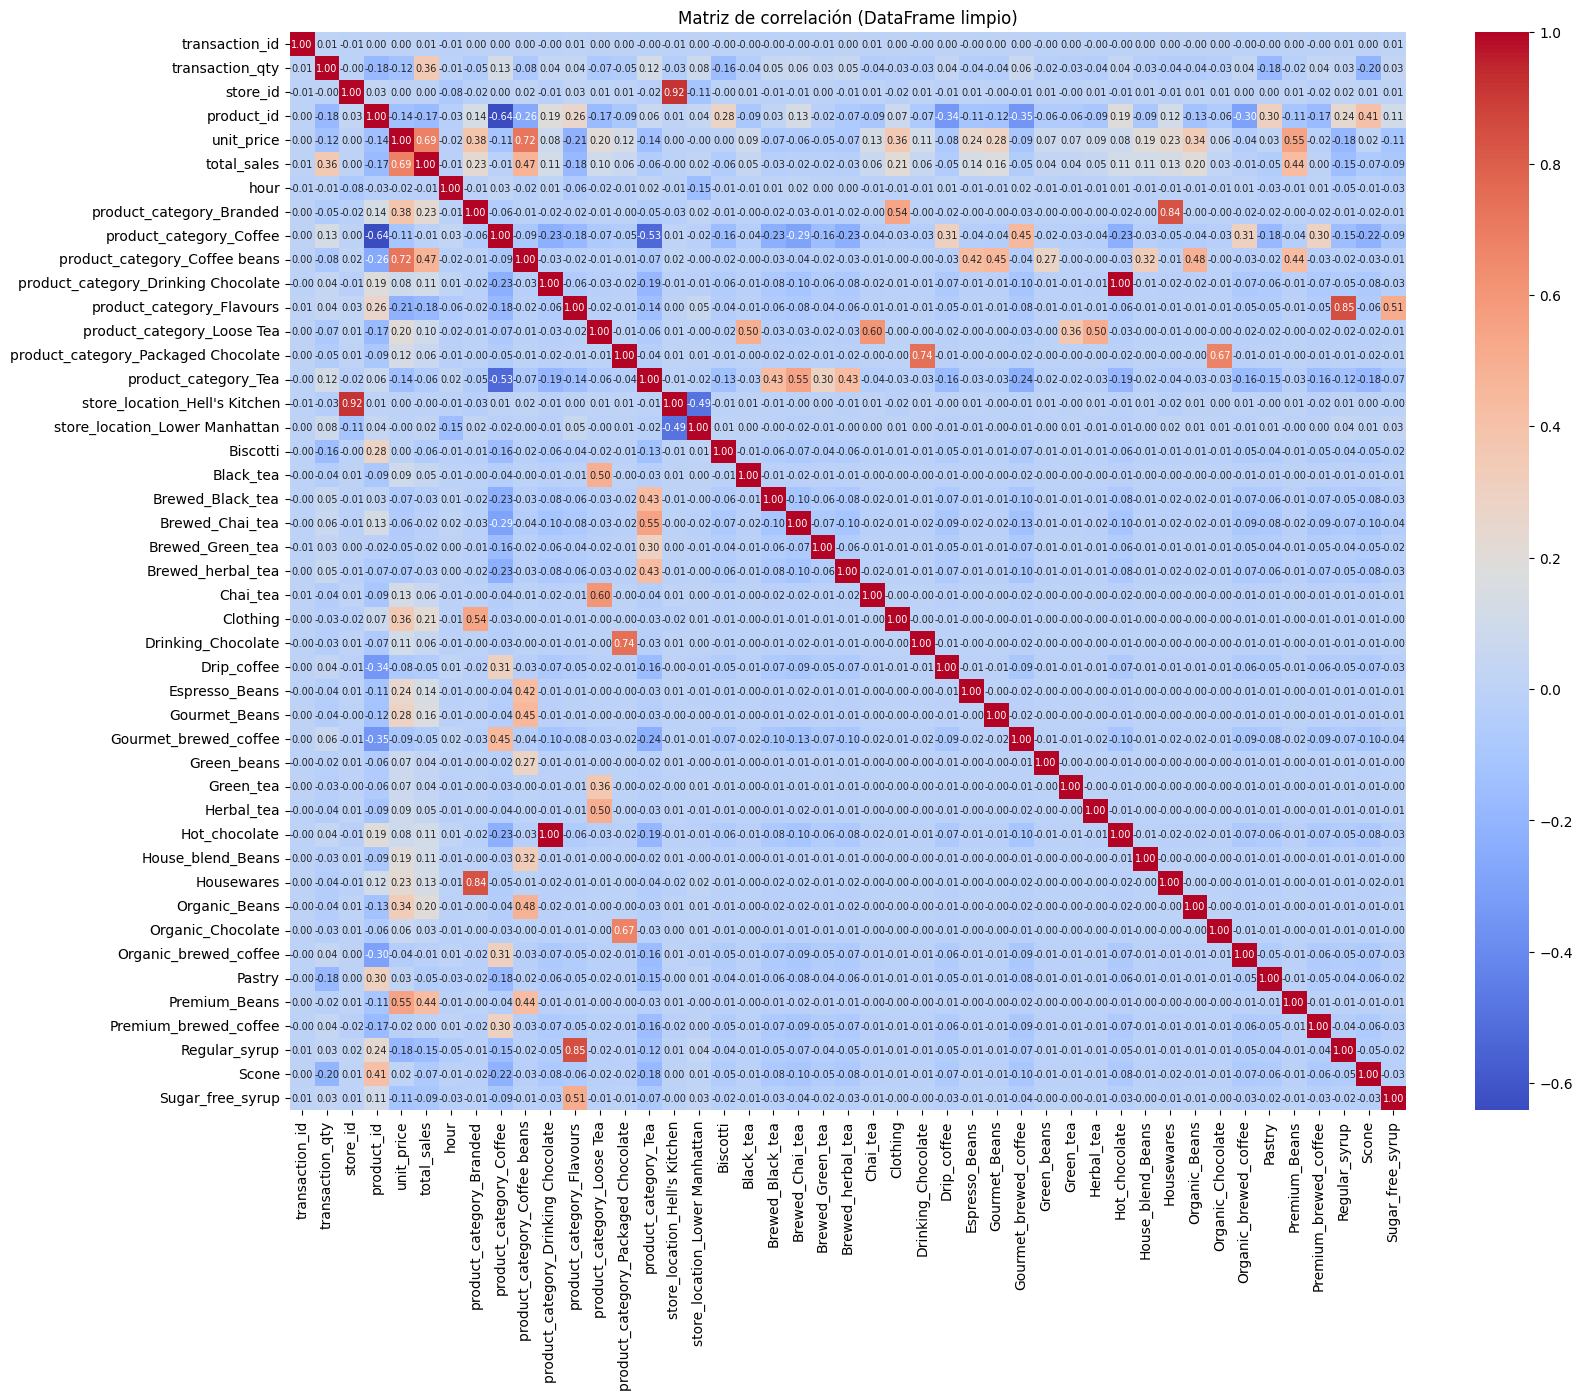

In [39]:
corr = df_final.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=ax,
    annot_kws={"size": 7}
)

plt.title("Matriz de correlación (DataFrame limpio)")
plt.show()

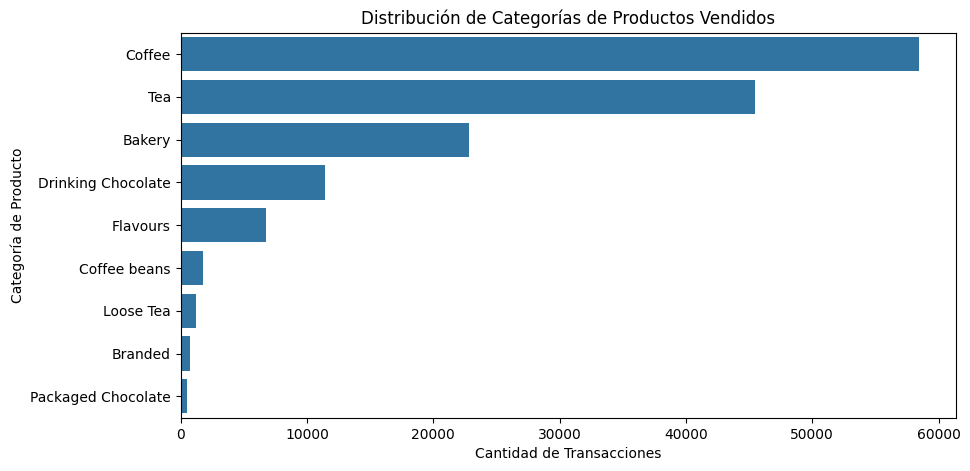

In [40]:
# Gráfico 1: Distribución de la variable objetivo
plt.figure(figsize=(10, 5))
sns.countplot(data=df_modelo, y='product_category',
              order=df_modelo['product_category'].value_counts().index)
plt.title('Distribución de Categorías de Productos Vendidos')
plt.xlabel('Cantidad de Transacciones')
plt.ylabel('Categoría de Producto')
plt.show()

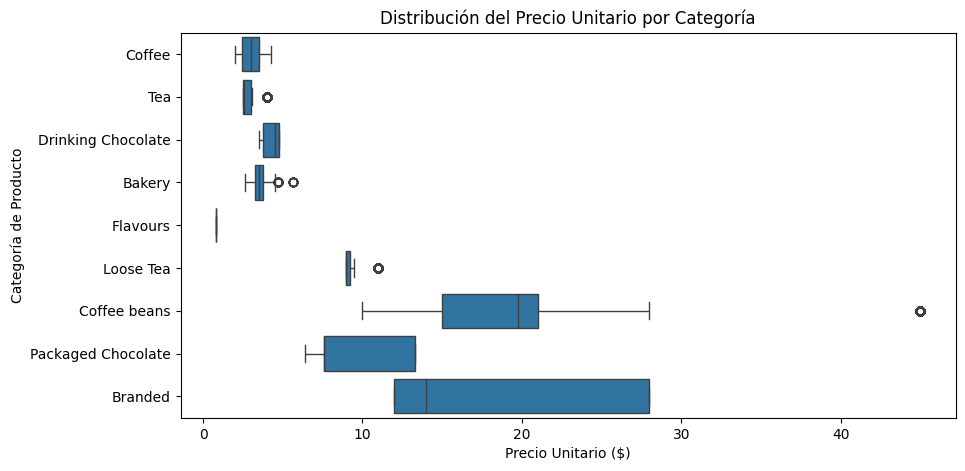

In [41]:
# Gráfico 2: Relación entre Precio Unitario y Categoría
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_modelo, x='unit_price', y='product_category')
plt.title('Distribución del Precio Unitario por Categoría')
plt.xlabel('Precio Unitario ($)')
plt.ylabel('Categoría de Producto')
plt.show()

Confirmamos que la categoría "Coffee" y "Tea" son las más demandadas.

Además, el gráfico de cajas demuestra que el precio unitario tiene rangos de valor muy definidos según la categoría, lo que lo convierte en una buena variable predictora.

## 5. Modelado
Especifique si se trata de clasificación o regresión y qué modelo(s) ha utilizado:

- Problema de clasificación
- Árbol de decisión
- Naive bayes

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Se establece una división 70-30 para entrenamiento y testing

In [44]:
modelo_arbol = DecisionTreeClassifier(max_depth=10, random_state=42)

In [45]:
modelo_nb = GaussianNB()

## 6. Entrenamiento y Evaluación
Describa los pasos del entrenamiento del modelo, conjunto de entrenamiento y prueba, métricas utilizadas (Accuracy, RMSE, R², etc.)


In [46]:
from sklearn.metrics import accuracy_score, classification_report

#Librerías para extraer métricas de desempeño modelo

In [47]:
modelo_arbol.fit(X_train, y_train)


#Entrenamos modelos

DecisionTreeClassifier(max_depth=10, random_state=42)

In [48]:
pred_arbol = modelo_arbol.predict(X_test)

In [49]:
print("="*40)
print(" RESULTADOS ÁRBOL DE DECISIÓN ")
print("="*40)
print(f"Accuracy (Exactitud): {accuracy_score(y_test, pred_arbol):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, pred_arbol, zero_division=0))

 RESULTADOS ÁRBOL DE DECISIÓN 
Accuracy (Exactitud): 0.6957

Reporte de Clasificación:
                    precision    recall  f1-score   support

            Bakery       0.62      0.50      0.56      6912
           Branded       0.98      0.99      0.98       230
            Coffee       0.68      0.60      0.64     17540
      Coffee beans       0.99      0.99      0.99       519
Drinking Chocolate       0.76      0.49      0.60      3503
          Flavours       1.00      1.00      1.00      2033
         Loose Tea       1.00      1.00      1.00       344
Packaged Chocolate       1.00      1.00      1.00       144
               Tea       0.67      0.89      0.76     13510

          accuracy                           0.70     44735
         macro avg       0.86      0.83      0.84     44735
      weighted avg       0.70      0.70      0.69     44735



In [50]:
modelo_nb.fit(X_train, y_train)

GaussianNB()

In [51]:
pred_nb = modelo_nb.predict(X_test)

In [52]:
print("\n" + "="*40)
print(" RESULTADOS NAIVE BAYES ")
print("="*40)
print(f"Accuracy (Exactitud): {accuracy_score(y_test, pred_nb):.4f}")


 RESULTADOS NAIVE BAYES 
Accuracy (Exactitud): 0.5614


Matriz de confusión

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [54]:
cm = confusion_matrix(y_test, pred_arbol)

In [55]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

<Figure size 800x600 with 0 Axes>

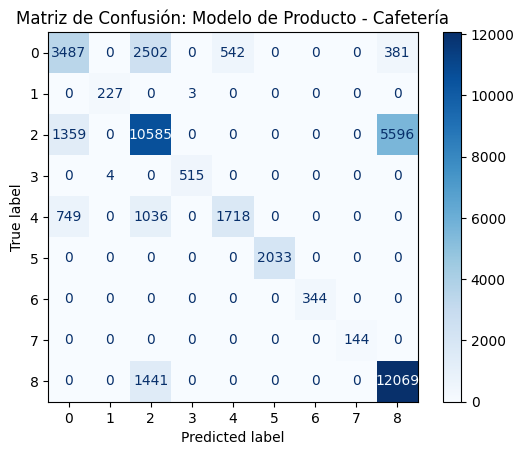

In [56]:
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión: Modelo de Producto - Cafetería")
plt.show()

## 7. Despliegue (opcional)
Explique cómo podría usarse el modelo en una aplicación real o simule un ejemplo.


In [57]:
def predecir_recomendacion(hora, ubicacion, precio_unitario):
    """
    Función que simula una API.
    Recibe los datos en tiempo real de la sucursal y predice el comportamiento del cliente.
    """
    nuevo_cliente = pd.DataFrame([{
        'hour': hora,
        'store_location': ubicacion,
        'unit_price': precio_unitario
    }])

    # Realizamos codificación
    ubicacion_codificada = ohe.transform(nuevo_cliente[['store_location']])

    # Convertir a DataFrame con los nombres de características correctos
    ubicacion_df = pd.DataFrame(
        ubicacion_codificada,
        columns=ohe.get_feature_names_out(['store_location']),
        index=nuevo_cliente.index
    )

    # Crear eje predictorio
    X_nuevo = pd.concat([nuevo_cliente[['hour', 'unit_price']], ubicacion_df], axis=1)

    # Realizar predicción con árbol de decisión
    prediccion = modelo_arbol.predict(X_nuevo)[0]

    # Calcular probabilidad del modelo para revisar la confianza en la predicción
    probabilidades = modelo_arbol.predict_proba(X_nuevo)
    prob_max = probabilidades.max() * 100

    print(f"Simulación - Ubicación: {ubicacion} | Hora: {hora}:00 hrs | Precio base: ${precio_unitario}")
    print(f"Predicción del Modelo: El cliente comprará un producto de la categoría '{prediccion}' (Confianza: {prob_max:.1f}%)")


## 8. Conclusiones
Resumen de hallazgos, utilidad del modelo, recomendaciones futuras.

Interpretación de resultados: El modelo de Árbol de Decisión presentó un mejor desempeño que Naive Bayes. Esto se debe sobre todo a que el precio unitario es un separador lógico fuerte para ciertas categorías.

Limitaciones del análisis: El modelo predice macro-categorías, pero agrupa una gran cantidad de detalles que se decidió no desglosar. Además, no estamos contemplando variables externas como el día de la semana o factores climáticos.

Aplicabilidad en contexto real: Este modelo podría implementarse en el backend del sistema de puntos de venta de alguna cafetería similar a la estudiada. Si un cliente se acerca a cierta hora del día, el sistema podría recomendar al cajero que producto ofrecer basándose en la probabilidad que propone el modelo.